# Imports

In [1]:
import json
import random
import h5py
import numpy as np
import matplotlib.pyplot as plt
from multiprocessing import Pool, cpu_count
import multiprocessing as mp
from functools import partial

import pyroomacoustics as pra
from pyroomacoustics.directivities import DirectionVector, CardioidFamily
from scipy.spatial import ConvexHull

# Config

In [2]:
tCFG = {
    "num_rirs": 1000,
    "sample_rate": 32000,

    "rir_max_length_sec": 3.0,

    "room": {
        "types": ["shoebox"], # or "random"
        "min_dim": [3.0, 3.0, 2.5],
        "max_dim": [10.0, 8.0, 4.0],
        "rt60_range": [0.2, 0.8],
        "num_sources": 6,
    },

    "materials": {
        "brick":  [0.03, 0.04, 0.05, 0.07, 0.08],
        "curtain": [0.2, 0.35, 0.55, 0.7, 0.7],
        "wood":   [0.1, 0.15, 0.2, 0.25, 0.3],
        "carpet": [0.15, 0.25, 0.4, 0.6, 0.65],
        "concrete":[0.01, 0.02, 0.02, 0.03, 0.04],
    },

    "mat_cfg": "square",
    "mic_array": {
        "tetrahedron": [
            [0.02, 0.0, 0.0],
            [-0.02, 0.0, 0.0],
            [0.0, 0.02, 0.0],
            [0.0, -0.02, 0.0],
        ],
        "square": [
            [0.02, 0.0, 0.0],
            [-0.02, 0.0, 0.0],
            [0.0, 0.02, 0.0],
            [0.0, -0.02, 0.0],
        ],
        "quasi_line": [
            [0.02, 0.0, 0.0],
            [-0.02, 0.0, 0.0],
            [0.0, 0.02, 0.0],
            [0.0, -0.02, 0.0],
        ],
    },

    "perturbations": {
        "mems_pos_std_m": 0.002,  # 2mm standard deviation
        "foa_rot_std_deg": 2.0    # 0 degrees standard deviation
    },

    "num_processes": max(1, cpu_count() - 1),  # Use all but one CPU core
}

vCFG = tCFG.copy()
vCFG["num_rirs"] //= 10

train_output_path = f"train_rir_dataset_{tCFG['mat_cfg']}_{tCFG['sample_rate']}hz_{tCFG['rir_max_length_sec']}s.h5"
valid_output_path = f"valid_rir_dataset_{vCFG['mat_cfg']}_{vCFG['sample_rate']}hz_{vCFG['rir_max_length_sec']}s.h5"

# Utilities

In [3]:
def random_room(cfg):
    dims = [random.uniform(cfg["min_dim"][i], cfg["max_dim"][i]) for i in range(3)]
    rt60 = random.uniform(*cfg["rt60_range"])
    room_type = random.choice(cfg["types"])
    return dims, rt60, room_type


def random_material(materials):
    key = random.choice(list(materials.keys()))
    coeffs = materials[key]
    return pra.Material({
        "coeffs": coeffs,
        "center_freqs": [125, 250, 500, 1000, 2000]
    }), key


def random_position_in_room(room, margin=0.5):
    # Min/max coordinates of the generated room
    room_dim = room.shoebox_dim

    pos = np.random.random(3) * (room_dim - margin * 2) + margin
    
    pos_array = pos.T.tolist()
    
    if room.is_inside(pos_array):
        return pos_array

    # Random position is out of bounds, fallback to just center
    center = room_dim / 2
    return center.tolist()

# Room Creation

In [ ]:
def create_room(dims, rt60, fs, material, room_type):
    e_absorption, max_order = pra.inverse_sabine(rt60, dims)
    max_order = min(max_order, 10)

    if room_type == "shoebox":
        room = pra.ShoeBox(
            dims,
            fs=fs,
            materials=material,
            max_order=max_order,
            absorption=e_absorption,
        )
    else:
        num_pts = random.randint(5, 8)
        points = np.random.rand(num_pts, 2) * np.array(dims[:2])
        
        hull = ConvexHull(points)

        # ConvexHull vertices are ordered counter-clockwise
        corners = points[hull.vertices].T

        room = pra.Room.from_corners(
            corners,
            fs=fs,
            materials=material,
            max_order=max_order,
            absorption=e_absorption,
        )
        room.extrude(dims[2])

    return room


def add_mems_and_foa(room, center, mic_positions, perturb_cfg):
    mems_pos_std = perturb_cfg["mems_pos_std_m"]
    foa_rot_std = perturb_cfg["foa_rot_std_deg"]

    center = np.array(center).reshape(3, 1)
    mic_positions = np.array(mic_positions).T

    mems_pos = center + mic_positions
    if mems_pos_std > 0:
        # Random noise to coords
        mems_pos += np.random.normal(loc=0.0, scale=mems_pos_std, size=mems_pos.shape)

    foa_pos = np.tile(center, (1, 4))

    all_positions = np.concatenate([mems_pos, foa_pos], axis=1)

    def noisy_angle(base_angle):
        angle = base_angle
        if foa_rot_std > 0:
            angle += np.random.normal(loc=0.0, scale=foa_rot_std)
            if angle < 0:
                angle = -angle
        return angle

    # FOA directions
    dir_x = CardioidFamily(
        orientation=DirectionVector(
            azimuth=noisy_angle(0), 
            colatitude=noisy_angle(90), 
            degrees=True
        ),
        p=0,
    )
    dir_y = CardioidFamily(
        orientation=DirectionVector(
            azimuth=noisy_angle(90), 
            colatitude=noisy_angle(90), 
            degrees=True
        ),
        p=0
    )
    dir_z = CardioidFamily(
        orientation=DirectionVector(
            azimuth=noisy_angle(0), 
            colatitude=noisy_angle(0), 
            degrees=True
        ),
        p=0
    )

    directivities = [
        None, None, None, None,  # MEMS
        None,                    # FOA W
        dir_x, dir_y, dir_z      # FOA X, Y, Z
    ]

    mic_array = pra.MicrophoneArray(all_positions, room.fs, directivity=directivities)
    room.add_microphone_array(mic_array)


def compute_rir(room, source_positions):
    for src_pos in source_positions:
        room.add_source(src_pos)
    room.compute_rir()
    return room.rir

# Visualization

In [5]:
def plot_rir(rir, title="RIR"):
    plt.figure(figsize=(10, 4))
    for ch in range(rir.shape[0]):
        plt.plot(rir[ch], label=f"ch{ch}")
    plt.title(title)
    plt.legend()
    plt.show()

# Generation Loop

In [ ]:
def generate_single_sample(args):
    cfg, seed = args
    
    random.seed(seed)
    np.random.seed(seed % (2**32))
    
    fs = cfg["sample_rate"]
    max_len = int(fs * cfg["rir_max_length_sec"])
    num_sources = cfg["room"]["num_sources"]
    
    # Generate room parameters
    dims, rt60, room_type = random_room(cfg["room"])
    material, mat_name = random_material(cfg["materials"])
    
    # Create room
    room = create_room(dims, rt60, fs, material, room_type)
    
    # Position microphone array
    mic_center = random_position_in_room(room, margin=0.5)
    
    # Generate multiple source positions
    src_positions = [
        random_position_in_room(room, margin=0.5)
        for _ in range(num_sources)
    ]
    
    # Add microphone array to room
    add_mems_and_foa(room, mic_center, cfg["mic_array"][cfg["mat_cfg"]], cfg["perturbations"])
    
    # Compute RIRs
    rir = compute_rir(room, src_positions)

    def pad_or_crop(arr):
        for mic_idx in range(len(arr)):
            for src_idx in range(len(arr[mic_idx])):
                a = arr[mic_idx][src_idx]
                if a.shape[0] < max_len:
                    a = np.pad(a, (0, max_len - a.shape[0]), mode="constant")
                else:
                    a = a[:max_len]
                arr[mic_idx][src_idx] = a

    # Pad/Crop RIRs
    pad_or_crop(rir)

    rir = np.array(rir)

    # (8, num_sources, max_len) -> (num_sources, 8, max_len)
    rir = np.moveaxis(rir, 0, 1)
    
    mems_rirs = rir[:, :4]
    foa_rirs  = rir[:, 4:]
    
    mic_pos = room.mic_array.R.tolist()
    
    # Return all data needed for this sample
    return {
        "mems_rirs": mems_rirs,  # (num_sources, 4, max_len)
        "foa_rirs": foa_rirs,    # (num_sources, 4, max_len)
        "meta": {
            "room_dim": dims,
            "room_type": room_type,
            "rt60": rt60,
            "material": mat_name,
            "mic_center": mic_center,
            "source_positions": src_positions,
            "actual_mic_positions": mic_pos,
        }
    }


def generate_dataset(cfg, output_path, num_processes=None):
    """Generate RIR dataset using multiprocessing."""
    if num_processes is None:
        num_processes = cfg.get("num_processes", max(1, cpu_count() - 1))
    
    fs = cfg["sample_rate"]
    max_len = int(fs * cfg["rir_max_length_sec"])
    num_sources = cfg["room"]["num_sources"]
    num_rirs = cfg["num_rirs"]
    
    print(f"Generating {num_rirs} RIRs using {num_processes} processes...")
    
    # Prepare arguments for each process
    args_list = [(cfg, i) for i in range(num_rirs)]
    
    # Generate samples
    with Pool(processes=num_processes) as pool:
        results = pool.map(generate_single_sample, args_list)
    
    print("Writing results to HDF5 file...")
    
    # Write results to HDF5 file
    with h5py.File(output_path, "w") as f:
        # Dataset shape: (num_rirs, num_sources, num_channels, max_len)
        mems_ds = f.create_dataset("rir/mems", (num_rirs, num_sources, 4, max_len), dtype="float32")
        foa_ds  = f.create_dataset("rir/foa",  (num_rirs, num_sources, 4, max_len), dtype="float32")
        
        meta = []
        
        # Write results to datasets
        for i, result in enumerate(results):
            mems_ds[i] = result["mems_rirs"]
            foa_ds[i] = result["foa_rirs"]
            meta.append(result["meta"])
        
        f.create_dataset("meta/json", data=str(json.dumps(meta)))
    
    print(f"Dataset saved to {output_path}")

Generating training DS...
Generating 1000 RIRs using 127 processes...
Writing results to HDF5 file...
Written 0/1000
Written 10/1000
Written 20/1000
Written 30/1000
Written 40/1000
Written 50/1000
Written 60/1000
Written 70/1000
Written 80/1000
Written 90/1000
Written 100/1000
Written 110/1000
Written 120/1000
Written 130/1000
Written 140/1000
Written 150/1000
Written 160/1000
Written 170/1000
Written 180/1000
Written 190/1000
Written 200/1000
Written 210/1000
Written 220/1000
Written 230/1000
Written 240/1000
Written 250/1000
Written 260/1000
Written 270/1000
Written 280/1000
Written 290/1000
Written 300/1000
Written 310/1000
Written 320/1000
Written 330/1000
Written 340/1000
Written 350/1000
Written 360/1000
Written 370/1000
Written 380/1000
Written 390/1000
Written 400/1000
Written 410/1000
Written 420/1000
Written 430/1000
Written 440/1000
Written 450/1000
Written 460/1000
Written 470/1000
Written 480/1000
Written 490/1000
Written 500/1000
Written 510/1000
Written 520/1000
Written 

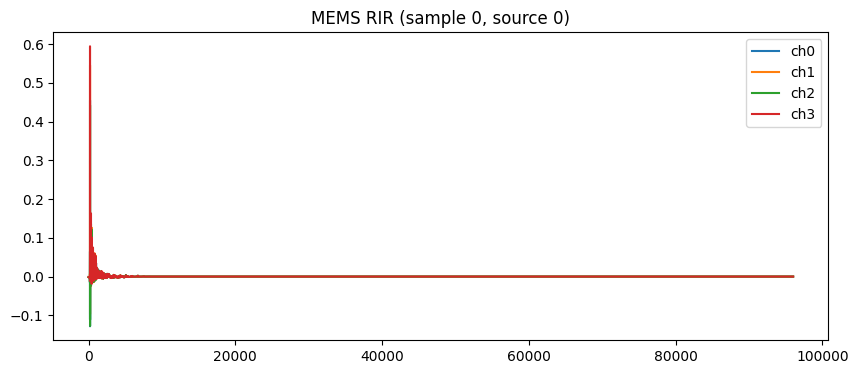

In [7]:
print("Generating training DS...")
generate_dataset(tCFG, train_output_path)

print("Generating validation DS...")
generate_dataset(vCFG, valid_output_path)

def inspect_sample(path, idx=0, src_idx=0):
    with h5py.File(path, "r") as f:
        mems = f["rir/mems"][idx, src_idx]

    plot_rir(mems, f"MEMS RIR (sample {idx}, source {src_idx})")

inspect_sample(train_output_path, 0, 0)